# 01 - Generating a Synthetic Credit Dataset with Known, Injected Bias

This notebook builds the single dataset used by every other notebook in this
project. Real fairness benchmarks (Adult, COMPAS, German Credit) have one
fatal weakness for a *library comparison*: nobody knows the true amount of
discrimination in them, so a fairness number can never be checked against a
reference. Here the data is generated, so the answer is known in advance.

## Design

Scenario: a bank's historical **loan approval** records.

| | |
|---|---|
| Rows | ~12,000 after sampling bias is applied |
| Target | `loan_approved` - the **observed, historically biased** decision |
| Sensitive attributes | `sex` (binary), `age_group` (binary), `race` (3 classes) |
| Model inputs | 11 features; **sensitive attributes are withheld** |

Withholding the sensitive attributes puts every downstream experiment in the
"fairness through unawareness" setting, which is what most production teams
actually deploy - and which mechanism B3 below is designed to defeat.

## The four injected bias mechanisms

| ID | Mechanism | How it is injected | What it should break |
|----|-----------|--------------------|----------------------|
| **B1** | Historical / label bias | Qualified applicants in unprivileged groups have their approval flipped 1 -> 0 with a group-specific probability | Demographic parity, equal opportunity |
| **B2** | Measurement bias | `credit_score` is observed with 3-4x more noise for unprivileged groups | Equalized odds, group-wise accuracy |
| **B3** | Proxy leakage | `career_gap_months` and `employment_type` track `sex`; `region` tracks `race` | The idea that dropping the sensitive column removes bias |
| **B4** | Representation bias | High-income women and `GroupC` applicants are undersampled | Minority-group precision, statistical power |

## Oracle columns

Because the process is synthetic, two counterfactual columns are recorded:

* `oracle_y_fair` - the approval decision **before** B1 was applied.
* `oracle_credit_score_true` - the credit score **before** B2 was applied.

They are never model inputs. They exist so that later notebooks can ask the
question no real dataset can answer: *how much of the injected bias did this
mitigation algorithm actually recover?*

In [1]:
# --- Setup -----------------------------------------------------------------
import json
import pathlib
import sys

# common.py lives in the project root, one level above this notebook.
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

import common

common.set_plot_style()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Every random draw in this notebook comes from this one generator, so the
# dataset is byte-identical on every re-run.
rng = np.random.default_rng(common.SEED)

common.environment_report()

,component,version
0,python,3.10.5
1,platform,Windows 10
2,executable,D:\.pyenv\pyenv-win\pyenv-win\versions\3.10.5\...
3,seed,42
4,numpy,2.2.5
5,pandas,2.2.3
6,scipy,1.15.2
7,sklearn,1.6.1
8,matplotlib,3.10.1
9,fairlearn,0.14.0


## Helper functions

`z` standardises a vector so that the coefficients further down are expressed
in standard-deviation units and are therefore directly comparable.

In [2]:
def z(values):
    # Standardise to zero mean / unit variance.
    values = np.asarray(values, dtype=float)
    return (values - values.mean()) / values.std()


def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-values))


# Generate a surplus of rows: mechanism B4 discards some of them later, and we
# want roughly 12,000 survivors.
N_RAW = 16_000

## 1. Population and sensitive attributes

The marginal distributions are deliberately unbalanced (55/45 on sex, 60/25/15
on race) because group-size imbalance is itself a source of unfairness: metrics
estimated on a small group have wide confidence intervals, and AIF360's
`consistency` and Fairlearn's `count` metric both surface this.

In [3]:
# --- Sensitive attributes --------------------------------------------------
sex = rng.choice(["Male", "Female"], size=N_RAW, p=[0.55, 0.45])
race = rng.choice(["GroupA", "GroupB", "GroupC"], size=N_RAW, p=[0.60, 0.25, 0.15])
age = np.clip(rng.normal(43, 13, N_RAW), 18, 78).round().astype(int)

# The binary age split at 55 is the one used by every fairness metric later.
age_group = np.where(age < 55, "under_55", "55_plus")

# Boolean masks reused throughout the notebook.
is_female = sex == "Female"
is_senior = age_group == "55_plus"
is_group_a = race == "GroupA"

pd.DataFrame(
    {
        "sex": pd.Series(sex).value_counts(normalize=True),
        "race": pd.Series(race).value_counts(normalize=True),
        "age_group": pd.Series(age_group).value_counts(normalize=True),
    }
).round(3)

,sex,race,age_group
55_plus,NaN,NaN,0.188
Female,0.452,NaN,NaN
GroupA,NaN,0.593,NaN
GroupB,NaN,0.258,NaN
GroupC,NaN,0.149,NaN
Male,0.548,NaN,NaN
under_55,NaN,NaN,0.812


## 2. Legitimate features, and the proxies that carry bias (mechanism B3)

Three of the features are deliberately built as **proxies** for a sensitive
attribute. This is the whole reason "just delete the sensitive column" fails:

* `career_gap_months` - women accumulate far more career gap (child-rearing,
  caregiving), so the column reconstructs `sex` almost on its own.
* `employment_type` - part-time work is much more common among women.
* `region` - residential segregation makes `region` informative about `race`.

A structural gap is also written into `education_years` and `income`. This is
not a modelling error, it mirrors reality: labour-market discrimination happens
*upstream* of the loan decision. It matters for the comparison because it is
the kind of disparity that **conditional** metrics (Fairlearn's
`control_features`) are designed to separate out from the rest.

In [4]:
# --- Human capital ---------------------------------------------------------
# Structural inequality: GroupA has had better access to education.
education_years = np.clip(rng.normal(13.6 + 0.9 * is_group_a, 2.4, N_RAW), 8, 22)

employment_years = np.clip(
    age - education_years - 6 + rng.normal(0, 3, N_RAW), 0, 45
)

# Experience predicts repayment with strongly diminishing returns: the tenth
# year of work history tells a lender far more than the thirtieth. Without this
# cap, `employment_years` grows monotonically with age and makes older
# applicants look genuinely more creditworthy, which would invert the age axis
# and make every age fairness metric read backwards. The cap was calibrated so
# that the fair label is approximately age-neutral.
EXPERIENCE_CAP = 10
experience = np.minimum(employment_years, EXPERIENCE_CAP)

# Late-career income decline and shorter repayment horizon.
late_career = np.maximum(age - 50, 0)

# --- PROXY 1: career gap tracks sex ---------------------------------------
# Most, but not all, women carry a long gap; a minority of men do too. Making
# the overlap non-empty keeps the proxy realistic (recovery AUC ~0.86) instead
# of degenerate (~1.00), which would make mechanism B3 trivially detectable.
FEMALE_GAP_SHARE = 0.75
MALE_GAP_SHARE = 0.12

has_long_gap = np.where(
    is_female,
    rng.random(N_RAW) < FEMALE_GAP_SHARE,
    rng.random(N_RAW) < MALE_GAP_SHARE,
)
career_gap_months = np.clip(
    rng.poisson(1.5, N_RAW) + has_long_gap * rng.poisson(11, N_RAW), 0, 96
).astype(int)

# --- PROXY 2: region tracks race (residential segregation) -----------------
region = np.empty(N_RAW, dtype=object)
region_probs = {
    "GroupA": [0.25, 0.55, 0.20],
    "GroupB": [0.55, 0.30, 0.15],
    "GroupC": [0.60, 0.20, 0.20],
}
for group, probs in region_probs.items():
    mask = race == group
    region[mask] = rng.choice(
        ["urban", "suburban", "rural"], size=int(mask.sum()), p=probs
    )

# --- PROXY 3: employment type tracks sex -----------------------------------
employment_type = np.empty(N_RAW, dtype=object)
employment_probs = {
    "Male": [0.78, 0.07, 0.15],
    "Female": [0.58, 0.27, 0.15],
}
for group, probs in employment_probs.items():
    mask = sex == group
    employment_type[mask] = rng.choice(
        ["fulltime", "parttime", "selfemployed"], size=int(mask.sum()), p=probs
    )

In [5]:
# --- Income ----------------------------------------------------------------
# The sex and race coefficients here encode upstream labour-market
# discrimination, i.e. bias that exists before the bank ever sees the file.
INCOME_AGE_PENALTY = 0.010

log_income = (
    10.20
    + 0.055 * (education_years - 13.6)
    + 0.020 * experience
    - INCOME_AGE_PENALTY * late_career
    - 0.004 * career_gap_months
    - 0.13 * is_female
    - 0.09 * (race == "GroupC")
    - 0.05 * (race == "GroupB")
    + 0.06 * (region == "suburban")
    - 0.05 * (region == "rural")
    - 0.20 * (employment_type == "parttime")
    + rng.normal(0, 0.35, N_RAW)
)
income = np.exp(log_income).round(-2)

# --- Credit history --------------------------------------------------------
default_rate = np.clip(0.60 - 0.25 * z(log_income), 0.02, 4.0)
num_prior_defaults = rng.poisson(default_rate).astype(int)

debt_to_income = np.clip(
    rng.beta(2.2, 5.5, N_RAW) * 1.2 + 0.05 * num_prior_defaults, 0.02, 0.95
)

loan_amount = np.clip(
    (income * np.clip(rng.lognormal(-0.55, 0.45, N_RAW), 0.05, 3.0)).round(-2),
    500,
    None,
)
has_cosigner = rng.binomial(1, 0.22, N_RAW)

# --- ORACLE: the noise-free credit score ----------------------------------
# This is the true underlying repayment signal. Mechanism B2 will corrupt the
# version that the model actually gets to see.
credit_score_true = np.clip(
    580
    + 45 * z(log_income)
    + 25 * z(experience)
    - 55 * num_prior_defaults
    - 60 * z(debt_to_income)
    + rng.normal(0, 25, N_RAW),
    300,
    850,
).round()

print(f"median income          : {np.median(income):,.0f}")
print(f"mean prior defaults    : {num_prior_defaults.mean():.2f}")
print(f"mean true credit score : {credit_score_true.mean():.0f}")

median income          : 28,600
mean prior defaults    : 0.60
mean true credit score : 548


## 3. The counterfactually fair label

`oracle_y_fair` is generated from **legitimate risk factors only** - the
noise-free credit score, income, employment history, education, debt burden,
prior defaults, loan-to-income ratio and whether there is a co-signer.

No sensitive attribute enters this equation. By construction, this is what the
approval decision would have looked like in a world without mechanism B1.

Note the subtlety: `oracle_y_fair` is *not* free of all group differences.
Because income and education already differ across groups (upstream
discrimination), the fair label still shows a residual gap. Distinguishing that
residual gap from the flat-out discriminatory gap added in the next section is
exactly what a good fairness toolkit has to help you do.

The age axis was explicitly calibrated. Left alone, `employment_years` grows
with age, making older applicants look genuinely lower-risk, and the nominally
unprivileged `55_plus` group ends up with the *higher* approval rate - which
would flip the sign of every age fairness metric downstream. Capping the
returns to experience at 10 years removes that artefact; a small repayment
horizon penalty then leaves a ~5pp legitimate age gap for the conditional
metrics to find.

In [6]:
# --- Latent creditworthiness ----------------------------------------------
HORIZON_PENALTY = 0.020

creditworthiness = (
    1.05 * z(credit_score_true)
    + 0.55 * z(log_income)
    + 0.30 * z(experience)
    + 0.20 * z(education_years)
    - 0.65 * z(debt_to_income)
    - 0.45 * z(num_prior_defaults)
    - 0.35 * z(np.log(loan_amount / income))
    + 0.25 * has_cosigner
    # A shorter remaining earning horizon is a legitimate risk factor, so this
    # term stays in the FAIR label. It leaves a small (~5pp) age gap that is
    # not discrimination - separating it from the discriminatory gap added by
    # B1 is precisely the job of a conditional / control-feature analysis.
    - HORIZON_PENALTY * late_career
)

# Shift the intercept so the overall approval rate lands near TARGET_BASE_RATE.
TARGET_BASE_RATE = 0.55
intercept = -np.quantile(creditworthiness, 1 - TARGET_BASE_RATE)
p_fair = sigmoid(creditworthiness + intercept)
oracle_y_fair = rng.binomial(1, p_fair)

print(f"fair approval rate overall : {oracle_y_fair.mean():.3f}")
for attribute, values in [("sex", sex), ("age_group", age_group), ("race", race)]:
    rates = pd.Series(oracle_y_fair).groupby(pd.Series(values)).mean().round(3)
    print(f"  by {attribute:10s}: {rates.to_dict()}")

fair approval rate overall : 0.529
  by sex       : {'Female': 0.477, 'Male': 0.572}
  by age_group : {'55_plus': 0.486, 'under_55': 0.539}
  by race      : {'GroupA': 0.556, 'GroupB': 0.492, 'GroupC': 0.486}


## 4. Mechanism B1 - historical / label bias

The bank's past loan officers systematically denied qualified applicants from
some groups. This is modelled as a one-directional flip: an applicant whose
fair label is `1` has it overwritten to `0` with a group-dependent probability.
Nobody is ever wrongly *approved*, which matches how documented lending
discrimination actually looks.

The per-group flip probabilities compose multiplicatively, so an applicant who
is in several unprivileged groups at once is hit hardest - this is what makes
the **intersectional** analysis in the Fairlearn notebook non-trivial.

In [7]:
# --- B1: historical label bias --------------------------------------------
FLIP_PROBABILITIES = {
    "female": 0.22,
    "senior": 0.15,
    "race_GroupB": 0.10,
    "race_GroupC": 0.18,
}

race_flip = np.select(
    [race == "GroupC", race == "GroupB"],
    [FLIP_PROBABILITIES["race_GroupC"], FLIP_PROBABILITIES["race_GroupB"]],
    default=0.0,
)

# Probability of surviving every applicable source of discrimination.
survive_probability = (
    (1 - FLIP_PROBABILITIES["female"] * is_female)
    * (1 - FLIP_PROBABILITIES["senior"] * is_senior)
    * (1 - race_flip)
)
flip_probability = 1 - survive_probability

loan_approved = oracle_y_fair.copy()
was_flipped = (oracle_y_fair == 1) & (rng.random(N_RAW) < flip_probability)
loan_approved[was_flipped] = 0

print(f"qualified applicants denied by B1: {was_flipped.sum():,} "
      f"({was_flipped.mean():.1%} of all rows)")

comparison = pd.DataFrame(
    {
        "fair_rate": pd.Series(oracle_y_fair).groupby(pd.Series(sex)).mean(),
        "observed_rate": pd.Series(loan_approved).groupby(pd.Series(sex)).mean(),
    }
)
comparison["gap_added_by_B1"] = comparison["fair_rate"] - comparison["observed_rate"]
comparison.round(3)

qualified applicants denied by B1: 1,379 (8.6% of all rows)


,fair_rate,observed_rate,gap_added_by_B1
Female,0.477,0.340,0.137
Male,0.572,0.528,0.044


## 5. Mechanism B2 - measurement bias

The feature the model sees, `credit_score`, is a *noisy reading* of the true
score. Credit bureaus hold thinner files on some populations, so the reading is
substantially noisier for women and for the non-majority race groups.

This is a different failure mode from B1 and it breaks a different metric. B1
shifts *who gets approved*; B2 degrades *how well the model can predict at
all* for a group, which shows up as unequal false-positive and false-negative
rates - i.e. an equalized-odds violation that no amount of relabelling fixes.

In [8]:
# --- B2: measurement bias --------------------------------------------------
NOISE_BASE = 12.0
NOISE_FEMALE_PENALTY = 20.0
NOISE_MINORITY_PENALTY = 22.0

noise_sd = (
    NOISE_BASE
    + NOISE_FEMALE_PENALTY * is_female
    + NOISE_MINORITY_PENALTY * (~is_group_a)
)

credit_score = np.clip(
    credit_score_true + rng.normal(0, noise_sd), 300, 850
).round()

measurement_error = np.abs(credit_score - credit_score_true)
pd.DataFrame(
    {
        "noise_sd_applied": pd.Series(noise_sd).groupby(pd.Series(sex)).mean(),
        "mean_abs_error": pd.Series(measurement_error).groupby(pd.Series(sex)).mean(),
    }
).round(2)

,noise_sd_applied,mean_abs_error
Female,41.01,31.80
Male,20.90,16.48


## 6. Mechanism B4 - representation bias

Finally, rows are dropped non-uniformly: high-income women are undersampled
(they were historically steered away from this product) and `GroupC` is
undersampled overall.

The consequence is statistical rather than moral: the model has less evidence
about exactly the sub-populations where the other mechanisms bite hardest, so
its estimates there are both worse and less certain.

In [9]:
# --- B4: representation bias ----------------------------------------------
DROP_HIGH_INCOME_FEMALE = 0.40
DROP_GROUP_C = 0.18

high_income = log_income > np.quantile(log_income, 0.60)
drop_probability = (
    DROP_HIGH_INCOME_FEMALE * (is_female & high_income)
    + DROP_GROUP_C * (race == "GroupC")
)
keep = rng.random(N_RAW) >= drop_probability

representation = pd.DataFrame(
    {
        "before": pd.Series(sex).value_counts(normalize=True),
        "after": pd.Series(sex[keep]).value_counts(normalize=True),
    }
)
representation_race = pd.DataFrame(
    {
        "before": pd.Series(race).value_counts(normalize=True),
        "after": pd.Series(race[keep]).value_counts(normalize=True),
    }
)
print(f"rows kept: {keep.sum():,} of {N_RAW:,}")
display(representation.round(3))
display(representation_race.round(3))

rows kept: 14,677 of 16,000


,before,after
Male,0.548,0.582
Female,0.452,0.418


,before,after
GroupA,0.593,0.606
GroupB,0.258,0.267
GroupC,0.149,0.127


## 7. Assemble the dataset

In [10]:
# --- Assemble --------------------------------------------------------------
full = pd.DataFrame(
    {
        # Sensitive attributes (not model inputs).
        "sex": sex,
        "age": age,
        "age_group": age_group,
        "race": race,
        # Model inputs.
        "income": income,
        "education_years": education_years.round(1),
        "employment_years": employment_years.round(1),
        "credit_score": credit_score,
        "debt_to_income": debt_to_income.round(4),
        "num_prior_defaults": num_prior_defaults,
        "loan_amount": loan_amount,
        "career_gap_months": career_gap_months,
        "region": region,
        "employment_type": employment_type,
        "has_cosigner": has_cosigner,
        # Observed, biased target.
        "loan_approved": loan_approved,
        # Oracle columns - never model inputs.
        "oracle_y_fair": oracle_y_fair,
        "oracle_credit_score_true": credit_score_true,
    }
)

# Apply mechanism B4 and reset the index so downstream joins are safe.
full = full.loc[keep].reset_index(drop=True)

# Sanity check: the declared schema and the actual frame must agree.
missing = set(common.FEATURES) - set(full.columns)
assert not missing, f"declared features missing from frame: {missing}"

print(full.shape)
full.head()

(14677, 18)

,sex,age,age_group,race,income,education_years,employment_years,credit_score,debt_to_income,num_prior_defaults,loan_amount,career_gap_months,region,employment_type,has_cosigner,loan_approved,oracle_y_fair,oracle_credit_score_true
0,Female,48,under_55,GroupB,15600.0,11.3,30.0,516.0,0.2440,2,9000.0,9,urban,parttime,0,0,0,458.0
1,Male,55,55_plus,GroupA,17100.0,13.2,43.4,505.0,0.4894,0,5000.0,1,rural,fulltime,0,0,0,507.0
2,Female,36,under_55,GroupA,43400.0,10.2,23.2,647.0,0.3308,0,17900.0,14,suburban,fulltime,0,0,1,616.0
3,Male,42,under_55,GroupA,40100.0,17.4,23.6,568.0,0.3604,1,32000.0,0,urban,fulltime,0,0,0,577.0
4,Female,46,under_55,GroupC,29800.0,13.6,21.7,681.0,0.0794,0,21200.0,2,rural,fulltime,0,0,1,679.0


## 8. Auditing the proxies (does B3 actually work?)

Before trusting the rest of the project, verify that dropping the sensitive
columns really does *not* hide the sensitive information. Each check below
trains a classifier that predicts a sensitive attribute from the **model input
features only**. An AUC well above 0.5 means the attribute is recoverable, and
therefore that "fairness through unawareness" is not going to save us.

In [11]:
# --- Proxy audit -----------------------------------------------------------
def proxy_auc(frame, target_binary, feature_subset=None):
    # Train a quick linear probe that reconstructs a sensitive attribute from
    # non-sensitive features, and report its AUC.
    columns = feature_subset or common.FEATURES
    design = pd.get_dummies(frame[columns], drop_first=True).astype(float)
    design = (design - design.mean()) / design.std().replace(0, 1)
    probe = LogisticRegression(max_iter=1000, random_state=common.SEED)
    probe.fit(design, target_binary)
    return roc_auc_score(target_binary, probe.predict_proba(design)[:, 1])


audit_rows = []
for attribute in common.SENSITIVE_COLUMNS:
    target_binary = common.binarize_sensitive(full, attribute)
    audit_rows.append(
        {
            "sensitive_attribute": attribute,
            "auc_all_features": proxy_auc(full, target_binary),
            "auc_named_proxies": proxy_auc(
                full,
                target_binary,
                ["career_gap_months", "employment_type", "region"],
            ),
        }
    )

proxy_audit = pd.DataFrame(audit_rows).round(3)
proxy_audit

,sensitive_attribute,auc_all_features,auc_named_proxies
0,sex,0.877,0.857
1,age_group,0.988,0.513
2,race,0.711,0.676


## 9. Train / test split

The split is stratified on the joint distribution of the target and all three
sensitive attributes, so no group is accidentally over- or under-represented in
one of the two halves. Every downstream notebook loads these exact files.

In [12]:
# --- Split -----------------------------------------------------------------
stratify_key = (
    full["loan_approved"].astype(str)
    + "_" + full["sex"]
    + "_" + full["age_group"]
    + "_" + full["race"]
)

train, test = train_test_split(
    full,
    test_size=0.30,
    random_state=common.SEED,
    stratify=stratify_key,
)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

common.DATA_DIR.mkdir(parents=True, exist_ok=True)
train.to_csv(common.TRAIN_CSV, index=False)
test.to_csv(common.TEST_CSV, index=False)

print(f"train: {train.shape} -> {common.TRAIN_CSV.name}")
print(f"test : {test.shape} -> {common.TEST_CSV.name}")
print()
print("approval rate by split:")
print(pd.DataFrame({"train": [train.loan_approved.mean()],
                    "test": [test.loan_approved.mean()]}).round(4).to_string(index=False))

train: (10273, 18) -> credit_train.csv
test : (4404, 18) -> credit_test.csv

approval rate by split:
 train   test
0.4426 0.4432


## 10. Visual diagnostics

Five figures, each isolating one injected mechanism. They are saved to
`figures/` so the evidence survives independently of the notebook outputs.

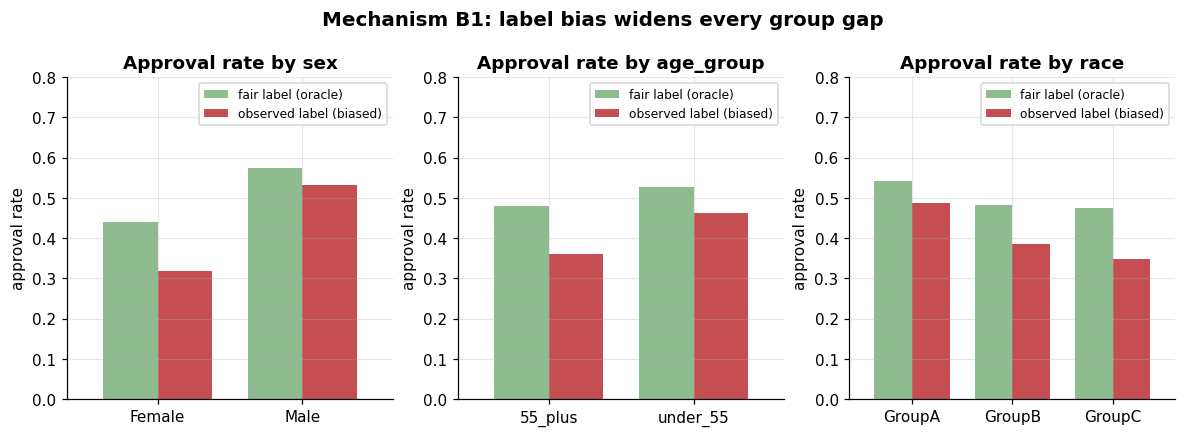

In [13]:
# --- Figure 1: the gap B1 opened up ---------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

for ax, attribute in zip(axes, common.SENSITIVE_COLUMNS):
    grouped = full.groupby(attribute)[["oracle_y_fair", "loan_approved"]].mean()
    grouped.columns = ["fair label (oracle)", "observed label (biased)"]
    grouped.plot(kind="bar", ax=ax, color=["#8FBC8F", "#C44E52"], rot=0, width=0.75)
    ax.set_title(f"Approval rate by {attribute}")
    ax.set_ylabel("approval rate")
    ax.set_xlabel("")
    ax.set_ylim(0, 0.8)
    ax.legend(fontsize=8)

fig.suptitle("Mechanism B1: label bias widens every group gap", y=1.04, fontsize=13, fontweight="bold")
common.savefig(fig, common.DATA_FIG_DIR, "fig1_label_bias_by_group.png")
plt.show()

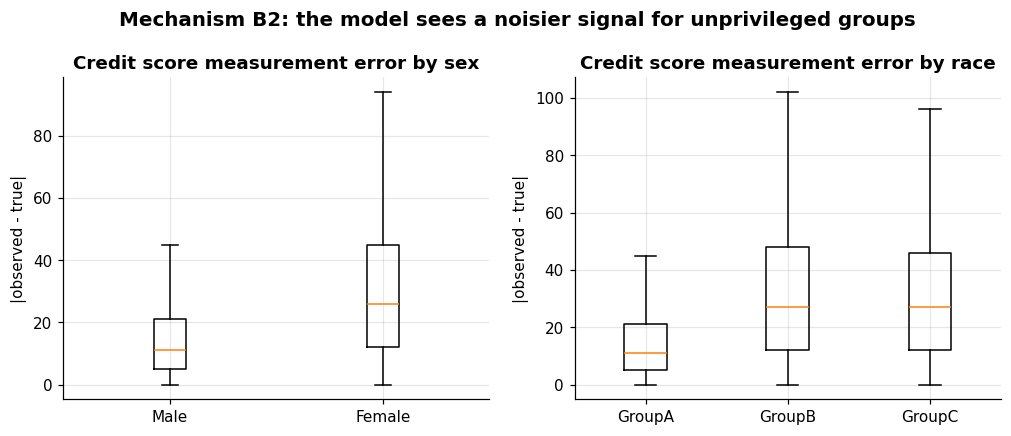

In [14]:
# --- Figure 2: measurement bias -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

error = (full["credit_score"] - full["oracle_credit_score_true"]).abs()

by_sex = [error[full.sex == g] for g in ["Male", "Female"]]
axes[0].boxplot(by_sex, tick_labels=["Male", "Female"], showfliers=False)
axes[0].set_title("Credit score measurement error by sex")
axes[0].set_ylabel("|observed - true|")

by_race = [error[full.race == g] for g in ["GroupA", "GroupB", "GroupC"]]
axes[1].boxplot(by_race, tick_labels=["GroupA", "GroupB", "GroupC"], showfliers=False)
axes[1].set_title("Credit score measurement error by race")
axes[1].set_ylabel("|observed - true|")

fig.suptitle("Mechanism B2: the model sees a noisier signal for unprivileged groups",
             y=1.04, fontsize=13, fontweight="bold")
common.savefig(fig, common.DATA_FIG_DIR, "fig2_measurement_bias.png")
plt.show()

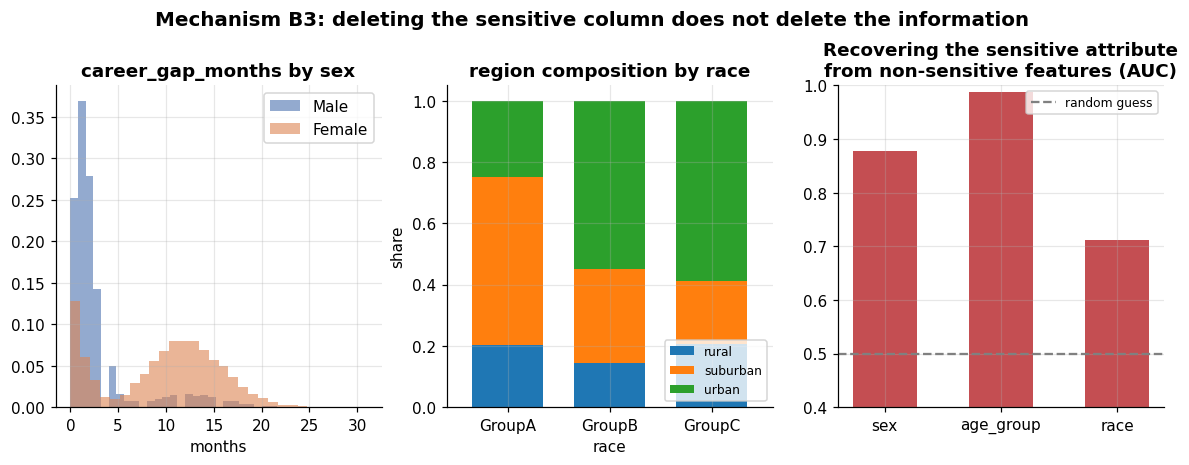

In [15]:
# --- Figure 3: proxy leakage ----------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

for group, colour in [("Male", common.PRIVILEGED_COLOR), ("Female", common.UNPRIVILEGED_COLOR)]:
    axes[0].hist(full.loc[full.sex == group, "career_gap_months"], bins=30,
                 alpha=0.6, label=group, color=colour, density=True)
axes[0].set_title("career_gap_months by sex")
axes[0].set_xlabel("months")
axes[0].legend()

region_by_race = pd.crosstab(full["race"], full["region"], normalize="index")
region_by_race.plot(kind="bar", stacked=True, ax=axes[1], rot=0, width=0.7)
axes[1].set_title("region composition by race")
axes[1].set_ylabel("share")
axes[1].legend(fontsize=8, loc="lower right")

axes[2].bar(proxy_audit["sensitive_attribute"], proxy_audit["auc_all_features"],
            color="#C44E52", width=0.55)
axes[2].axhline(0.5, ls="--", c="grey", label="random guess")
axes[2].set_ylim(0.4, 1.0)
axes[2].set_title("Recovering the sensitive attribute\nfrom non-sensitive features (AUC)")
axes[2].legend(fontsize=8)

fig.suptitle("Mechanism B3: deleting the sensitive column does not delete the information",
             y=1.06, fontsize=13, fontweight="bold")
common.savefig(fig, common.DATA_FIG_DIR, "fig3_proxy_leakage.png")
plt.show()

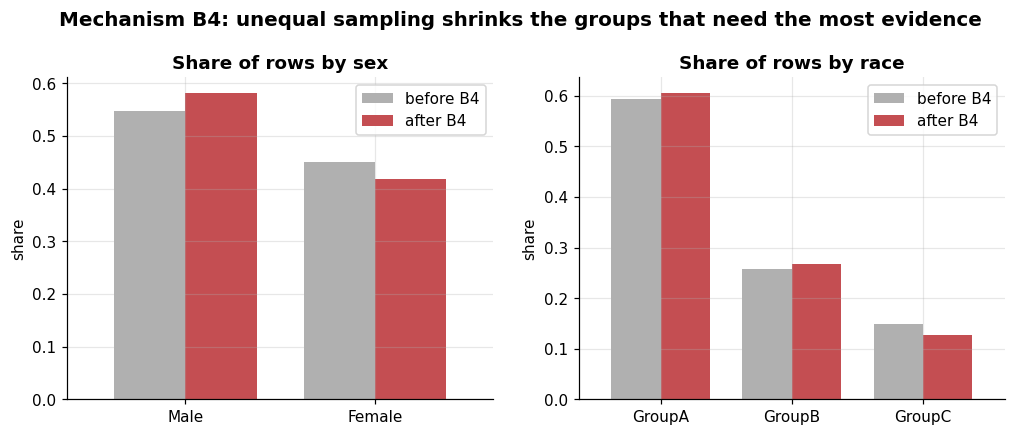

In [16]:
# --- Figure 4: representation bias ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

sex_repr = pd.DataFrame(
    {"before B4": pd.Series(sex).value_counts(normalize=True),
     "after B4": full["sex"].value_counts(normalize=True)}
)
sex_repr.plot(kind="bar", ax=axes[0], rot=0, width=0.75, color=["#B0B0B0", "#C44E52"])
axes[0].set_title("Share of rows by sex")
axes[0].set_ylabel("share")

race_repr = pd.DataFrame(
    {"before B4": pd.Series(race).value_counts(normalize=True),
     "after B4": full["race"].value_counts(normalize=True)}
)
race_repr.plot(kind="bar", ax=axes[1], rot=0, width=0.75, color=["#B0B0B0", "#C44E52"])
axes[1].set_title("Share of rows by race")
axes[1].set_ylabel("share")

fig.suptitle("Mechanism B4: unequal sampling shrinks the groups that need the most evidence",
             y=1.04, fontsize=13, fontweight="bold")
common.savefig(fig, common.DATA_FIG_DIR, "fig4_representation_bias.png")
plt.show()

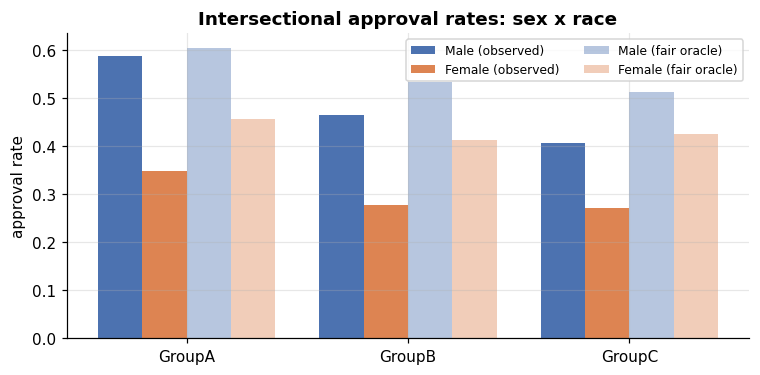

race,GroupA,GroupB,GroupC
sex,,,
Female,0.348,0.277,0.271
Male,0.587,0.464,0.407


In [17]:
# --- Figure 5: intersectional view ----------------------------------------
# The multiplicative composition of B1 means the joint groups are not simply
# the sum of the marginal effects. This is the figure the Fairlearn
# intersectional MetricFrame will later reproduce from model predictions.
fig, ax = plt.subplots(figsize=(8, 3.6))

joint = (
    full.groupby(["sex", "race"])["loan_approved"].mean().unstack()
)
joint_fair = (
    full.groupby(["sex", "race"])["oracle_y_fair"].mean().unstack()
)

positions = np.arange(len(joint.columns))
width = 0.2
for offset, (label, frame, colour) in enumerate(
    [("Male", joint.loc["Male"], "#4C72B0"), ("Female", joint.loc["Female"], "#DD8452")]
):
    ax.bar(positions + offset * width, frame.values, width, label=f"{label} (observed)", color=colour)
for offset, (label, frame) in enumerate([("Male", joint_fair.loc["Male"]), ("Female", joint_fair.loc["Female"])]):
    ax.bar(positions + 2 * width + offset * width, frame.values, width,
           label=f"{label} (fair oracle)", color="#4C72B0" if label == "Male" else "#DD8452", alpha=0.4)

ax.set_xticks(positions + 1.5 * width)
ax.set_xticklabels(joint.columns)
ax.set_ylabel("approval rate")
ax.set_title("Intersectional approval rates: sex x race")
ax.legend(fontsize=8, ncol=2)

common.savefig(fig, common.DATA_FIG_DIR, "fig5_intersectional.png")
plt.show()

display(joint.round(3))

## 11. Persisting the ground truth

Everything a later notebook needs in order to grade a mitigation algorithm is
written to `data/ground_truth.json`: the injected parameters *and* the
disparities they actually produced in this particular realisation.

In [18]:
# --- Record the ground truth ----------------------------------------------
def rate_table(frame, attribute):
    return {
        str(k): round(float(v), 4)
        for k, v in frame.groupby(attribute)["loan_approved"].mean().items()
    }


def fair_rate_table(frame, attribute):
    return {
        str(k): round(float(v), 4)
        for k, v in frame.groupby(attribute)["oracle_y_fair"].mean().items()
    }


ground_truth = {
    "seed": common.SEED,
    "n_raw": int(N_RAW),
    "n_final": int(len(full)),
    "n_train": int(len(train)),
    "n_test": int(len(test)),
    "target_base_rate": TARGET_BASE_RATE,
    "calibration": {
        # Chosen so that the fair label is close to age-neutral; see section 2.
        "experience_cap_years": EXPERIENCE_CAP,
        "horizon_penalty_per_year_over_50": HORIZON_PENALTY,
        "income_age_penalty_per_year_over_50": INCOME_AGE_PENALTY,
        "female_long_gap_share": FEMALE_GAP_SHARE,
        "male_long_gap_share": MALE_GAP_SHARE,
    },
    "mechanisms": {
        "B1_label_bias": {
            "description": "Qualified applicants in unprivileged groups have "
                           "their approval flipped 1 -> 0.",
            "flip_probabilities": FLIP_PROBABILITIES,
            "composition": "multiplicative across attributes",
            "rows_flipped": int(was_flipped.sum()),
        },
        "B2_measurement_bias": {
            "description": "credit_score is a noisy reading of "
                           "oracle_credit_score_true.",
            "noise_sd_base": NOISE_BASE,
            "noise_sd_female_penalty": NOISE_FEMALE_PENALTY,
            "noise_sd_minority_penalty": NOISE_MINORITY_PENALTY,
        },
        "B3_proxy_leakage": {
            "description": "Non-sensitive features encode sensitive attributes.",
            "proxies": {
                "sex": ["career_gap_months", "employment_type"],
                "race": ["region"],
            },
            "recovery_auc": proxy_audit.set_index("sensitive_attribute")[
                "auc_all_features"
            ].to_dict(),
        },
        "B4_representation_bias": {
            "description": "Non-uniform row dropout.",
            "drop_high_income_female": DROP_HIGH_INCOME_FEMALE,
            "drop_group_c": DROP_GROUP_C,
            "rows_dropped": int(N_RAW - keep.sum()),
        },
    },
    "realised_disparities": {},
}

for attribute in common.SENSITIVE_COLUMNS:
    observed = rate_table(full, attribute)
    fair = fair_rate_table(full, attribute)
    privileged = common.SENSITIVE_SPECS[attribute]["privileged"]
    unprivileged = common.SENSITIVE_SPECS[attribute]["unprivileged"]
    unprivileged_keys = (
        unprivileged if isinstance(unprivileged, list) else [unprivileged]
    )
    unprivileged_rate = float(
        np.mean([observed[k] for k in unprivileged_keys])
    )
    unprivileged_fair_rate = float(
        np.mean([fair[k] for k in unprivileged_keys])
    )
    ground_truth["realised_disparities"][attribute] = {
        "observed_rate_by_group": observed,
        "fair_rate_by_group": fair,
        # The gap a fairness metric will measure on the raw data.
        "observed_statistical_parity_difference": round(
            unprivileged_rate - observed[privileged], 4
        ),
        # The part of that gap that survives even without B1, i.e. the residual
        # caused by upstream inequality in income and education.
        "fair_statistical_parity_difference": round(
            unprivileged_fair_rate - fair[privileged], 4
        ),
        # The part attributable purely to the injected label bias.
        "gap_attributable_to_B1": round(
            (unprivileged_fair_rate - fair[privileged])
            - (unprivileged_rate - observed[privileged]),
            4,
        ),
    }

with open(common.GROUND_TRUTH_JSON, "w", encoding="utf-8") as handle:
    json.dump(ground_truth, handle, indent=2)

print(f"wrote {common.GROUND_TRUTH_JSON}")
print(json.dumps(ground_truth["realised_disparities"], indent=2))

wrote E:\Repo\bias mitigation\01_data_generation\data\ground_truth.json
{
  "sex": {
    "observed_rate_by_group": {
      "Female": 0.3185,
      "Male": 0.532
    },
    "fair_rate_by_group": {
      "Female": 0.4402,
      "Male": 0.5739
    },
    "observed_statistical_parity_difference": -0.2135,
    "fair_statistical_parity_difference": -0.1337,
    "gap_attributable_to_B1": 0.0798
  },
  "age_group": {
    "observed_rate_by_group": {
      "55_plus": 0.3599,
      "under_55": 0.4621
    },
    "fair_rate_by_group": {
      "55_plus": 0.4792,
      "under_55": 0.527
    },
    "observed_statistical_parity_difference": -0.1022,
    "fair_statistical_parity_difference": -0.0478,
    "gap_attributable_to_B1": 0.0544
  },
  "race": {
    "observed_rate_by_group": {
      "GroupA": 0.4882,
      "GroupB": 0.3845,
      "GroupC": 0.3487
    },
    "fair_rate_by_group": {
      "GroupA": 0.543,
      "GroupB": 0.4819,
      "GroupC": 0.4749
    },
    "observed_statistical_parity_differ

In [19]:
# --- Write the data dictionary --------------------------------------------
COLUMN_DOCS = [
    ("sex", "sensitive", "Male / Female. Privileged: Male."),
    ("age", "sensitive (raw)", "Years, 18-78. Withheld from the model."),
    ("age_group", "sensitive", "under_55 / 55_plus. Privileged: under_55."),
    ("race", "sensitive", "GroupA / GroupB / GroupC. Privileged: GroupA."),
    ("income", "feature", "Annual income. Carries an upstream sex and race gap."),
    ("education_years", "feature", "Years of schooling, 8-22."),
    ("employment_years", "feature", "Years of work history, 0-45."),
    ("credit_score", "feature", "300-850. Corrupted by mechanism B2."),
    ("debt_to_income", "feature", "Ratio, 0.02-0.95."),
    ("num_prior_defaults", "feature", "Count of past defaults."),
    ("loan_amount", "feature", "Requested principal."),
    ("career_gap_months", "feature", "PROXY for sex (mechanism B3)."),
    ("region", "feature", "urban / suburban / rural. PROXY for race (B3)."),
    ("employment_type", "feature", "fulltime / parttime / selfemployed. PROXY for sex (B3)."),
    ("has_cosigner", "feature", "0/1."),
    ("loan_approved", "target", "Observed, historically biased decision. 1 = approved."),
    ("oracle_y_fair", "oracle", "Approval before B1. NEVER a model input."),
    ("oracle_credit_score_true", "oracle", "Credit score before B2. NEVER a model input."),
]

lines = [
    "# Data dictionary - synthetic credit approval dataset",
    "",
    f"Generated by `01_generate_biased_credit_data.ipynb` with seed {common.SEED}.",
    f"Rows: {len(full):,} total ({len(train):,} train / {len(test):,} test).",
    "",
    "| column | role | description |",
    "|--------|------|-------------|",
]
lines += [f"| `{name}` | {role} | {description} |" for name, role, description in COLUMN_DOCS]
lines += [
    "",
    "## Roles",
    "",
    "* **feature** - passed to the model. See `common.FEATURES`.",
    "* **sensitive** - used for fairness analysis, withheld from the model.",
    "* **oracle** - counterfactual ground truth, available only because the",
    "  data is synthetic. Used to grade mitigation algorithms, never as input.",
    "",
]

schema_path = common.DATA_DIR / "schema.md"
schema_path.write_text("\n".join(lines), encoding="utf-8")
print(f"wrote {schema_path}")

wrote E:\Repo\bias mitigation\01_data_generation\data\schema.md


## 12. Summary

Artefacts written to `01_data_generation/data/`:

| file | contents |
|------|----------|
| `credit_train.csv` | 70% split, with oracle columns |
| `credit_test.csv` | 30% split, with oracle columns |
| `ground_truth.json` | injected parameters + the disparities they produced |
| `schema.md` | data dictionary |

And to `01_data_generation/figures/`: one figure per injected mechanism.

### What the next notebooks should find

If the generator did its job, a plain unaware classifier trained on this data
will show:

1. A large **demographic parity** violation on `sex` - mostly from B1.
2. An **equalized odds** violation that persists even after the selection rates
   are equalised - that one is B2, and it is a genuinely different problem.
3. Bias that **survives dropping the sensitive columns** - that is B3.
4. Noticeably wider metric spread on `GroupC` - that is B4.

Notebook `02_fairlearn/02a_fairlearn_detection.ipynb` and
`03_aif360/03a_aif360_detection.ipynb` each measure this same model with their
own toolkit, so the two APIs can be compared on identical numbers.